In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#Read in file
df = pd.read_csv(
    "https://raw.githubusercontent.com/GloBIAS-BioimageAnalysts/Survey_2024/main/data/survey2024_headersandcommascleaned_recleaned.csv"
)

In [4]:
#Clean data
df.columns = df.columns.str.strip().str.replace('\n', ' ', regex=True)

In [5]:
df['What is your location'] = df['What is your location'].replace({
    'Australia/ Oceania': 'Australia/Oceania',
    'Near/ Middle East': 'Middle East'
})

In [7]:
region_col = 'What is your location'

region_counts = (
    df[region_col]
    .value_counts(dropna=False)
    .rename_axis('Region')
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)

region_counts['Percent'] = 100 * region_counts['Count'] / region_counts['Count'].sum()
region_counts

,Region,Count,Percent
0,Europe,178,61.379310
1,North America,46,15.862069
2,South America,28,9.655172
3,Australia/Oceania,12,4.137931
4,Asia,10,3.448276
5,Middle East,8,2.758621
6,Africa,6,2.068966
7,Central America,1,0.344828
8,NaN,1,0.344828


In [8]:
df = df.rename(columns={
    'What is your gender': 'Gender'
})

In [9]:
summary_table = (
    df
    .dropna(subset=[region_col, 'Gender'])
    .groupby([region_col, 'Gender'])
    .size()
    .unstack(fill_value=0)
)

# Add percentages
summary_pct = summary_table.div(summary_table.sum(axis=1), axis=0) * 100

summary_table, summary_pct.round(1)

(Gender                 Female  Male  Other  Prefer not to say
 What is your location                                        
 Africa                      3     3      0                  0
 Asia                        4     6      0                  0
 Australia/Oceania           5     7      0                  0
 Central America             0     1      0                  0
 Europe                     66   106      1                  4
 Middle East                 3     4      0                  1
 North America              17    26      0                  3
 South America              16    11      0                  1,
 Gender                 Female   Male  Other  Prefer not to say
 What is your location                                         
 Africa                   50.0   50.0    0.0                0.0
 Asia                     40.0   60.0    0.0                0.0
 Australia/Oceania        41.7   58.3    0.0                0.0
 Central America           0.0  100.0    0.0     

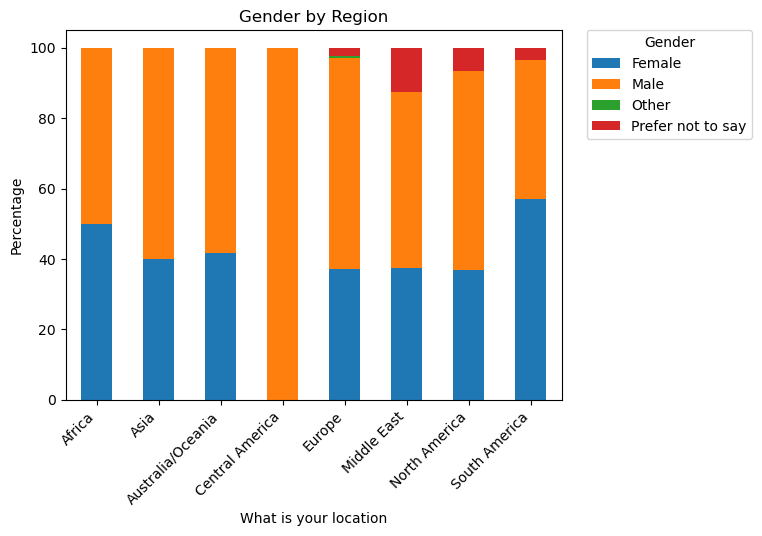

In [15]:
summary_pct.plot(
    kind='bar',
    stacked=True
)

plt.ylabel('Percentage')
plt.title('Gender by Region')
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.xticks(rotation=45, ha='right')
plt.show()